# Analyse exploratoire - Bank Marketing

**Objectif :** comprendre la structure, la qualité et les variables du jeu de données
avant la modélisation, et justifier les choix de prétraitement.

Ce notebook ne contient que l'analyse et les graphiques. Les calculs réutilisables
sont définis dans `src/bank_marketing/` et testés avec `pytest`. Les figures retenues
pour le rapport sont enregistrées dans `reports/figures/`.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from bank_marketing.domain.exploration import (
    compute_subscription_rate,
    rank_categorical_associations,
    summarize_target,
    summarize_unknown_values,
)
from bank_marketing.infrastructure.data import load_raw_data
from bank_marketing.infrastructure.figures import save_figure

sns.set_theme(style="whitegrid")
TARGET_PALETTE = {"no": "#E76F51", "yes": "#2A9D8F"}

## 1. Chargement et structure des données

In [2]:
data = load_raw_data()
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

Le jeu contient **4 119 clients** et **21 colonnes** : 20 variables explicatives et
la cible `y` (souscription à un dépôt à terme). Aucune valeur manquante technique
n'est présente.

## 2. Variable cible

In [4]:
summarize_target(data)

,effectif,pourcentage
souscription,,
no,3668,89.05
yes,451,10.95


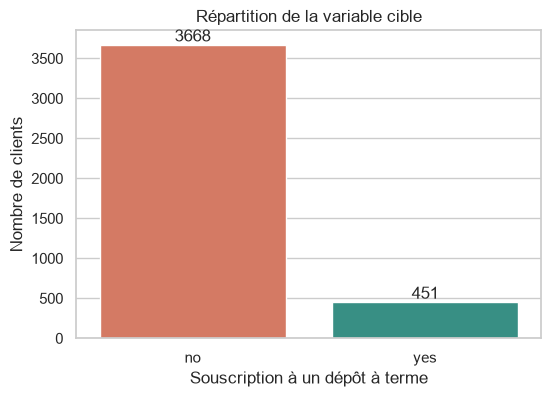

In [5]:
figure, axis = plt.subplots(figsize=(6, 4))
sns.countplot(data=data, x="y", hue="y", palette=TARGET_PALETTE, legend=False, ax=axis)
axis.set(
    title="Répartition de la variable cible",
    xlabel="Souscription à un dépôt à terme",
    ylabel="Nombre de clients",
)
for container in axis.containers:
    axis.bar_label(container)
save_figure(figure, "distribution_cible")
plt.show()

La cible est **déséquilibrée** : environ 11 % des clients souscrivent. L'accuracy
n'est donc pas une métrique adaptée (prédire « non » pour tout le monde donnerait
89 %). Les modèles seront évalués avec le **ROC-AUC**, le **PR-AUC**, la
**précision**, le **rappel** et le **F1-score**.

## 3. Qualité des données : modalités `unknown` et valeur sentinelle de `pdays`

In [6]:
summarize_unknown_values(data)

,nombre_unknown,part_unknown_pct,taux_souscription_unknown_pct,taux_souscription_connu_pct
variable,,,,
default,803,19.50,6.10,12.12
education,167,4.05,15.57,10.75
housing,105,2.55,8.57,11.01
loan,105,2.55,8.57,11.01
job,39,0.95,10.26,10.96
marital,11,0.27,9.09,10.95


Plusieurs variables catégorielles contiennent la modalité `unknown`. Elle n'est pas
une valeur manquante classique : pour `default`, les clients `unknown` souscrivent
nettement moins que ceux dont l'information est connue. Cette modalité porte donc
une information.

**Décision :** les modalités `unknown` sont **conservées comme des catégories à part
entière**, sans remplacement arbitraire.

In [7]:
share_never_contacted = data["pdays"].eq(999).mean()
print(f"Part des clients avec pdays = 999 : {share_never_contacted:.2%}")

Part des clients avec pdays = 999 : 96.12%


Pour 96 % des clients, `pdays` vaut 999 : cette valeur signifie « jamais contacté
lors d'une campagne précédente » et non un délai de 999 jours.

**Décision :** `pdays` est remplacée par un indicateur binaire
`previously_contacted`.

## 4. Variables numériques

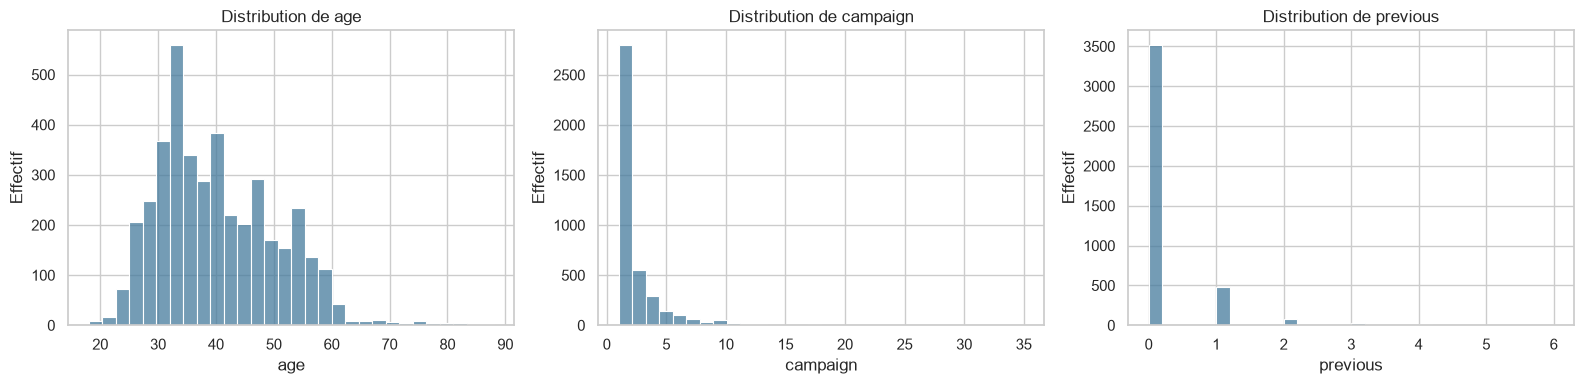

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, column in zip(axes, ["age", "campaign", "previous"], strict=True):
    sns.histplot(data=data, x=column, bins=30, color="#457B9D", ax=axis)
    axis.set(title=f"Distribution de {column}", ylabel="Effectif")
figure.tight_layout()
save_figure(figure, "distributions_numeriques")
plt.show()

- L'âge médian est d'environ 38 ans.
- `campaign` est très asymétrique : la plupart des clients sont contactés une à trois
  fois, certains jusqu'à 35 fois.
- `previous` est concentrée sur 0 : la plupart des clients n'ont jamais été
  contactés auparavant.

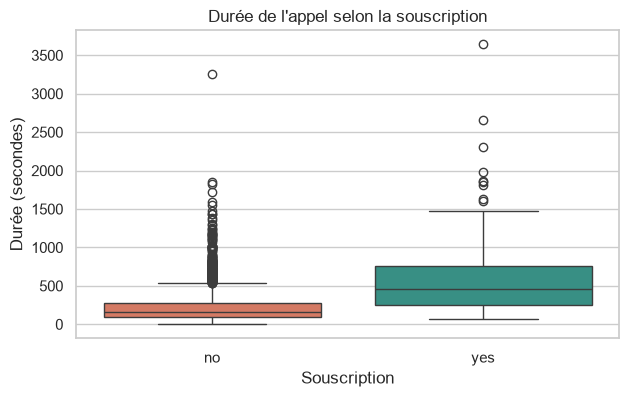

In [9]:
figure, axis = plt.subplots(figsize=(7, 4))
sns.boxplot(data=data, x="y", y="duration", hue="y", palette=TARGET_PALETTE, legend=False, ax=axis)
axis.set(
    title="Durée de l'appel selon la souscription",
    xlabel="Souscription",
    ylabel="Durée (secondes)",
)
plt.show()

`duration` est très liée à la souscription, mais elle n'est connue **qu'après**
l'appel : l'utiliser pour décider qui appeler serait une **fuite d'information**.

**Décision :** `duration` est **exclue** des variables explicatives.

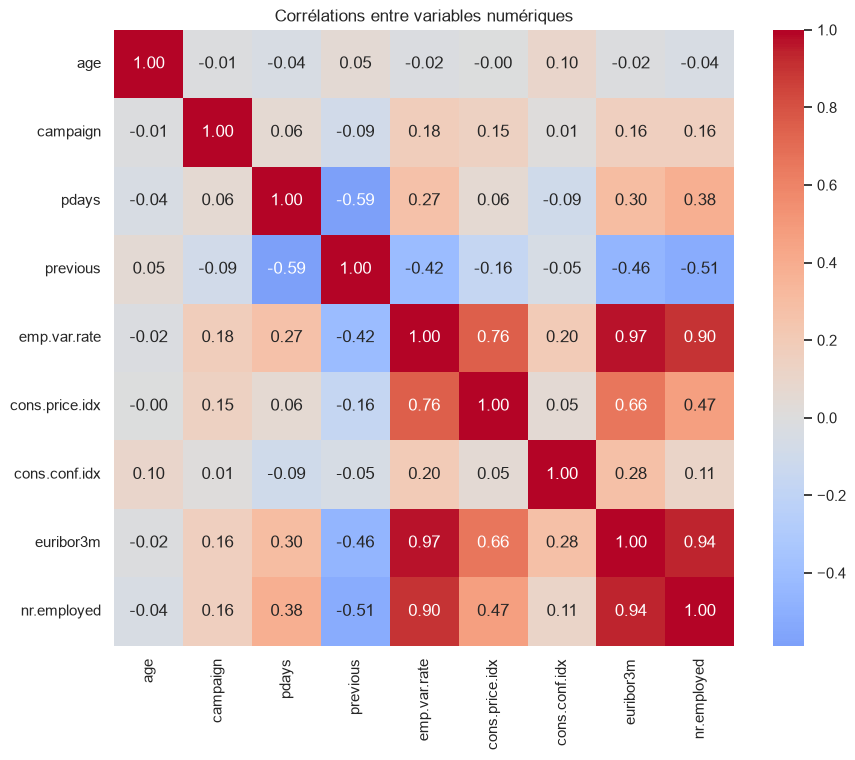

In [10]:
numeric_data = data.select_dtypes(include="number").drop(columns="duration")

figure, axis = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axis)
axis.set_title("Corrélations entre variables numériques")
save_figure(figure, "correlations_numeriques")
plt.show()

Les variables macroéconomiques `emp.var.rate`, `euribor3m` et `nr.employed` sont
**très fortement corrélées** : elles portent une information largement redondante.

**Décision :** deux jeux de variables sont comparés lors de la modélisation :
le jeu **complet**, et un jeu **interprétable** qui ne garde que `euribor3m`.

## 5. Variables catégorielles et souscription

In [11]:
categorical_columns = data.select_dtypes(exclude="number").columns.drop("y").tolist()
rank_categorical_associations(data, categorical_columns)

,v_cramer,p_value
variable,,
poutcome,0.332,2.039413e-99
month,0.270,2.894875e-59
contact,0.137,1.848000e-18
job,0.130,1.233132e-10
default,0.077,5.599508e-06
education,0.074,2.262143e-03
marital,0.050,1.628573e-02
loan,0.017,5.684489e-01
housing,0.012,7.307440e-01


Le **V de Cramér** mesure l'association entre chaque variable et la cible
(0 : aucune, 1 : parfaite). `poutcome` (résultat de la campagne précédente) et
`month` sont les variables les plus liées à la souscription. `housing`, `loan` et
`day_of_week` n'apportent presque rien.

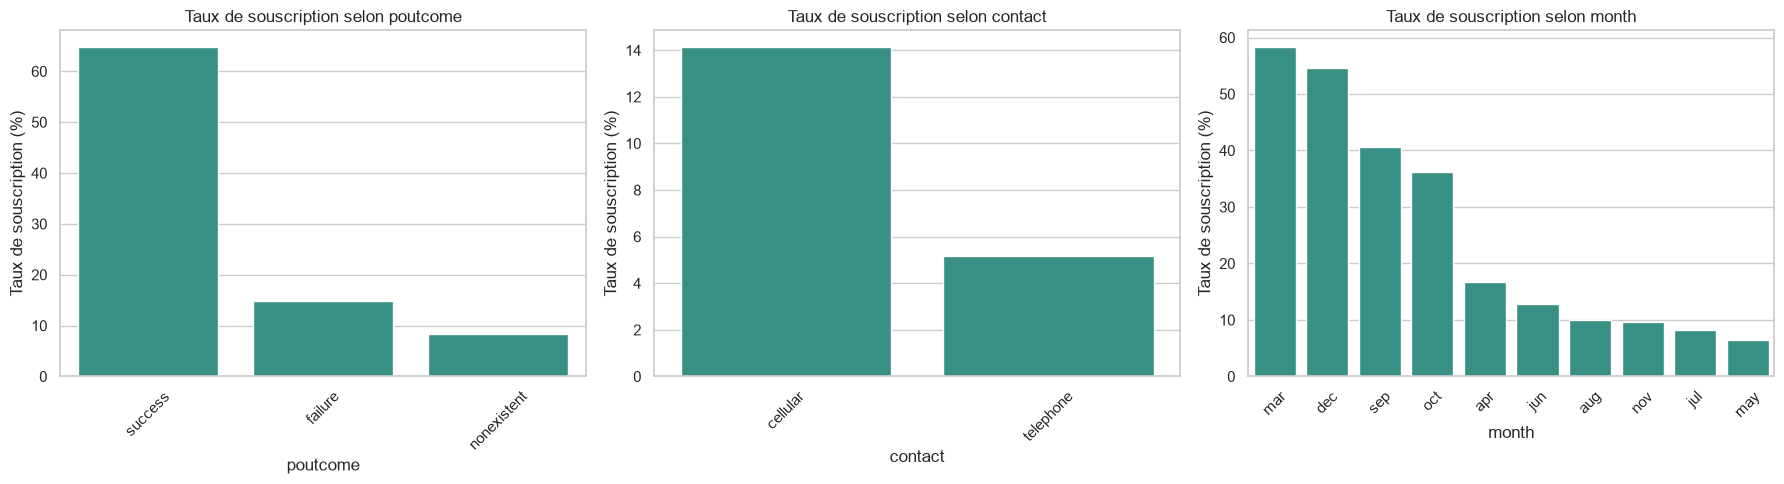

In [12]:
figure, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, column in zip(axes, ["poutcome", "contact", "month"], strict=True):
    rates = compute_subscription_rate(data, column).reset_index()
    sns.barplot(data=rates, x=column, y="taux_souscription_pct", color="#2A9D8F", ax=axis)
    axis.set(title=f"Taux de souscription selon {column}", ylabel="Taux de souscription (%)")
    axis.tick_params(axis="x", rotation=45)
figure.tight_layout()
save_figure(figure, "taux_souscription_categories")
plt.show()

In [13]:
compute_subscription_rate(data, "month")

,effectif,souscriptions,taux_souscription_pct
month,,,
mar,48,28,58.33
dec,22,12,54.55
sep,64,26,40.62
oct,69,25,36.23
apr,215,36,16.74
jun,530,68,12.83
aug,636,64,10.06
nov,446,43,9.64
jul,711,59,8.30


- Un **succès lors d'une campagne précédente** est associé à un taux de souscription
  bien plus élevé : c'est le signal le plus fort.
- Les clients contactés sur **mobile** souscrivent davantage que ceux contactés sur
  téléphone fixe.
- Le taux varie fortement selon le **mois**. Mars, septembre, octobre et décembre ont
  des taux élevés mais des **effectifs faibles** : à interpréter avec prudence.

## 6. Synthèse et décisions de prétraitement

| Élément | Constat | Décision |
|---|---|---|
| `y` | Cible déséquilibrée (≈ 11 % de souscriptions) | Cible binaire 1/0 ; métriques adaptées (PR-AUC, F1…) ; `class_weight="balanced"` |
| `duration` | Connue seulement après l'appel | Exclue (fuite d'information) |
| `pdays` | 999 = jamais contacté (96 % des clients) | Remplacée par `previously_contacted` |
| Modalités `unknown` | Informatives (taux de souscription différent) | Conservées comme catégories |
| Variables macroéconomiques | Très corrélées entre elles | Jeu complet et jeu interprétable comparés |
| Variables catégorielles | Pas d'ordre naturel | Encodage one-hot dans le pipeline |

Ces décisions sont implémentées dans `src/bank_marketing/domain/preprocessing.py`
et vérifiées par les tests de `tests/unit/test_preprocessing.py`.